In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df = pd.read_csv('/content/Carbon Emission.csv')
print("DataFrame 'df' loaded successfully. First 5 rows:")
df.head()

DataFrame 'df' loaded successfully. First 5 rows:


,Body Type,Sex,Diet,How Often Shower,Heating Energy Source,Transport,Vehicle Type,Social Activity,Monthly Grocery Bill,Frequency of Traveling by Air,Vehicle Monthly Distance Km,Waste Bag Size,Waste Bag Weekly Count,How Long TV PC Daily Hour,How Many New Clothes Monthly,How Long Internet Daily Hour,Energy efficiency,Recycling,Cooking_With,CarbonEmission
0,overweight,female,pescatarian,daily,coal,public,NaN,often,230,frequently,210,large,4,7,26,1,No,['Metal'],"['Stove', 'Oven']",2238
1,obese,female,vegetarian,less frequently,natural gas,walk/bicycle,NaN,often,114,rarely,9,extra large,3,9,38,5,No,['Metal'],"['Stove', 'Microwave']",1892
2,overweight,male,omnivore,more frequently,wood,private,petrol,never,138,never,2472,small,1,14,47,6,Sometimes,['Metal'],"['Oven', 'Microwave']",2595
3,overweight,male,omnivore,twice a day,wood,walk/bicycle,NaN,sometimes,157,rarely,74,medium,3,20,5,7,Sometimes,"['Paper', 'Plastic', 'Glass', 'Metal']","['Microwave', 'Grill', 'Airfryer']",1074
4,obese,female,vegetarian,daily,coal,private,diesel,often,266,very frequently,8457,large,1,3,5,6,Yes,['Paper'],['Oven'],4743


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   Body Type                      10000 non-null  object
 1   Sex                            10000 non-null  object
 2   Diet                           10000 non-null  object
 3   How Often Shower               10000 non-null  object
 4   Heating Energy Source          10000 non-null  object
 5   Transport                      10000 non-null  object
 6   Vehicle Type                   3279 non-null   object
 7   Social Activity                10000 non-null  object
 8   Monthly Grocery Bill           10000 non-null  int64 
 9   Frequency of Traveling by Air  10000 non-null  object
 10  Vehicle Monthly Distance Km    10000 non-null  int64 
 11  Waste Bag Size                 10000 non-null  object
 12  Waste Bag Weekly Count         10000 non-null  int64 
 13  Ho

In [ ]:
print("Missing values per column:")
df.isnull().sum()

Missing values per column:


,0
Body Type,0
Sex,0
Diet,0
How Often Shower,0
Heating Energy Source,0
Transport,0
Vehicle Type,6721
Social Activity,0
Monthly Grocery Bill,0
Frequency of Traveling by Air,0


In [ ]:
df['Vehicle Type'].fillna('Not Applicable', inplace=True)
print("Missing values after imputation:")
df.isnull().sum()

Missing values after imputation:


/tmp/ipykernel_306/56701175.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Vehicle Type'].fillna('Not Applicable', inplace=True)


,0
Body Type,0
Sex,0
Diet,0
How Often Shower,0
Heating Energy Source,0
Transport,0
Vehicle Type,0
Social Activity,0
Monthly Grocery Bill,0
Frequency of Traveling by Air,0


In [ ]:
categorical_cols = df.select_dtypes(include='object').columns
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
print("DataFrame after one-hot encoding. First 5 rows:")
df_encoded.head()

DataFrame after one-hot encoding. First 5 rows:


,Monthly Grocery Bill,Vehicle Monthly Distance Km,Waste Bag Weekly Count,How Long TV PC Daily Hour,How Many New Clothes Monthly,How Long Internet Daily Hour,CarbonEmission,Body Type_obese,Body Type_overweight,Body Type_underweight,...,Cooking_With_['Oven'],"Cooking_With_['Stove', 'Grill', 'Airfryer']","Cooking_With_['Stove', 'Microwave', 'Grill', 'Airfryer']","Cooking_With_['Stove', 'Microwave']","Cooking_With_['Stove', 'Oven', 'Grill', 'Airfryer']","Cooking_With_['Stove', 'Oven', 'Microwave', 'Grill', 'Airfryer']","Cooking_With_['Stove', 'Oven', 'Microwave']","Cooking_With_['Stove', 'Oven']",Cooking_With_['Stove'],Cooking_With_[]
0,230,210,4,7,26,1,2238,False,True,False,...,False,False,False,False,False,False,False,True,False,False
1,114,9,3,9,38,5,1892,True,False,False,...,False,False,False,True,False,False,False,False,False,False
2,138,2472,1,14,47,6,2595,False,True,False,...,False,False,False,False,False,False,False,False,False,False
3,157,74,3,20,5,7,1074,False,True,False,...,False,False,False,False,False,False,False,False,False,False
4,266,8457,1,3,5,6,4743,True,False,False,...,True,False,False,False,False,False,False,False,False,False


In [ ]:
X = df_encoded.drop('CarbonEmission', axis=1)
y = df_encoded['CarbonEmission']

print("Features (X) first 5 rows:")
print(X.head())
print("\nTarget (y) first 5 rows:")
print(y.head())

Features (X) first 5 rows:
   Monthly Grocery Bill  Vehicle Monthly Distance Km  Waste Bag Weekly Count  \
0                   230                          210                       4   
1                   114                            9                       3   
2                   138                         2472                       1   
3                   157                           74                       3   
4                   266                         8457                       1   

   How Long TV PC Daily Hour  How Many New Clothes Monthly  \
0                          7                            26   
1                          9                            38   
2                         14                            47   
3                         20                             5   
4                          3                             5   

   How Long Internet Daily Hour  Body Type_obese  Body Type_overweight  \
0                             1            Fa

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (8000, 66)
Shape of X_test: (2000, 66)
Shape of y_train: (8000,)
Shape of y_test: (2000,)


In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


In [ ]:
y_pred = model.predict(X_test)
print("Predictions generated successfully. First 5 predictions:")
print(y_pred[:5])

Predictions generated successfully. First 5 predictions:
[ 893.13746057 1721.23561369 2139.37561152 2993.46754536 2470.49659928]


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared (R2): {r2:.2f}")

Mean Absolute Error (MAE): 175.63
Mean Squared Error (MSE): 68441.94
R-squared (R2): 0.93


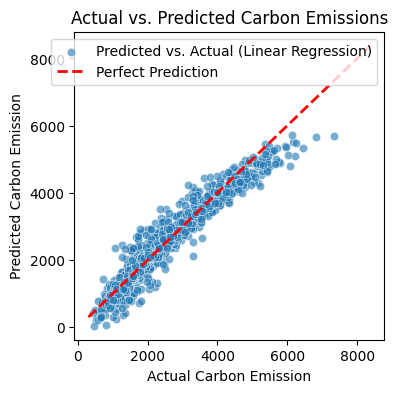

Plot for actual vs. predicted carbon emissions displayed successfully.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(4, 4))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6, label='Predicted vs. Actual (Linear Regression)')

# Add a perfect prediction line
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label='Perfect Prediction')

plt.xlabel('Actual Carbon Emission')
plt.ylabel('Predicted Carbon Emission')
plt.title('Actual vs. Predicted Carbon Emissions')
plt.legend()
plt.show()
print("Plot for actual vs. predicted carbon emissions displayed successfully.")

In [ ]:
from sklearn.linear_model import Ridge

ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)





Ridge()

In [ ]:
import sklearn.preprocessing

In [ ]:
results = {}

# Evaluate Linear Regression model
mae_lr = mean_absolute_error(y_test, y_pred)
mse_lr = mean_squared_error(y_test, y_pred)
r2_lr = r2_score(y_test, y_pred)

results['Linear Regression'] = {
    'MAE': mae_lr,
    'MSE': mse_lr,
    'R2': r2_lr
}

print("Linear Regression metrics stored in results dictionary.")

Linear Regression metrics stored in results dictionary.


In [ ]:
y_pred_ridge = ridge_model.predict(X_test)

# Evaluate Ridge Regression model
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

results['Ridge Regression'] = {
    'MAE': mae_ridge,
    'MSE': mse_ridge,
    'R2': r2_ridge
}

print("Ridge Regression metrics stored in results dictionary.")
print("\nFull results dictionary:")
print(results)

Ridge Regression metrics stored in results dictionary.

Full results dictionary:
{'Linear Regression': {'MAE': 175.62675416241314, 'MSE': 68441.94189977228, 'R2': 0.9341719789400711}, 'Ridge Regression': {'MAE': 175.58373283165264, 'MSE': 68421.17360255045, 'R2': 0.9341919540586745}}


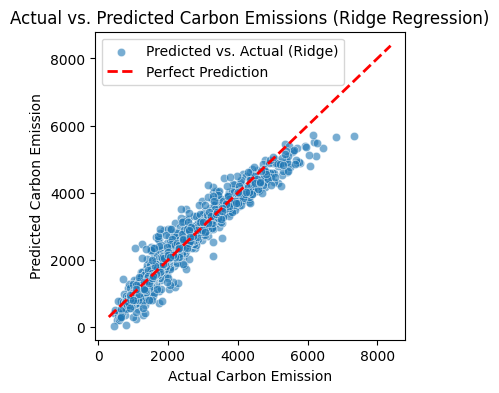

Plot for actual vs. predicted carbon emissions for Ridge Regression displayed successfully.


In [ ]:
plt.figure(figsize=(4, 4))
sns.scatterplot(x=y_test, y=y_pred_ridge, alpha=0.6, label='Predicted vs. Actual (Ridge)')

# Add a perfect prediction line
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label='Perfect Prediction')

plt.xlabel('Actual Carbon Emission')
plt.ylabel('Predicted Carbon Emission')
plt.title('Actual vs. Predicted Carbon Emissions (Ridge Regression)')
plt.legend()
plt.show()
print("Plot for actual vs. predicted carbon emissions for Ridge Regression displayed successfully.")


In [ ]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.linear_model import Lasso, ElasticNet, BayesianRidge

print("Necessary libraries for new regression models imported.")

Necessary libraries for new regression models imported.


In [ ]:
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

model_poly = LinearRegression()
model_poly.fit(X_train_poly, y_train)

y_pred_poly = model_poly.predict(X_test_poly)

mae_poly = mean_absolute_error(y_test, y_pred_poly)
mse_poly = mean_squared_error(y_test, y_pred_poly)
r2_poly = r2_score(y_test, y_pred_poly)

results['Polynomial Regression'] = {
    'MAE': mae_poly,
    'MSE': mse_poly,
    'R2': r2_poly
}

print("Polynomial Regression model trained and evaluated successfully.")
print(f"Mean Absolute Error (MAE): {mae_poly:.2f}")
print(f"Mean Squared Error (MSE): {mse_poly:.2f}")
print(f"R-squared (R2): {r2_poly:.2f}")
print("\nFull results dictionary:")
print(results)

Polynomial Regression model trained and evaluated successfully.
Mean Absolute Error (MAE): 70.71
Mean Squared Error (MSE): 8663.77
R-squared (R2): 0.99

Full results dictionary:
{'Linear Regression': {'MAE': 175.62675416241314, 'MSE': 68441.94189977228, 'R2': 0.9341719789400711}, 'Ridge Regression': {'MAE': 175.58373283165264, 'MSE': 68421.17360255045, 'R2': 0.9341919540586745}, 'Polynomial Regression': {'MAE': 70.713701693148, 'MSE': 8663.770591833572, 'R2': 0.9916671143870699}}


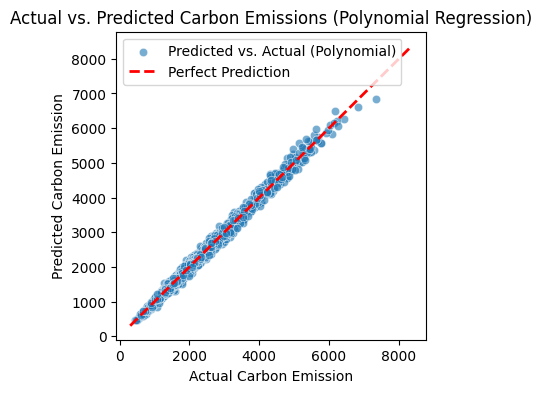

Plot for actual vs. predicted carbon emissions for Polynomial Regression displayed successfully.


In [ ]:
plt.figure(figsize=(4, 4))
sns.scatterplot(x=y_test, y=y_pred_poly, alpha=0.6, label='Predicted vs. Actual (Polynomial)')

# Add a perfect prediction line
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label='Perfect Prediction')

plt.xlabel('Actual Carbon Emission')
plt.ylabel('Predicted Carbon Emission')
plt.title('Actual vs. Predicted Carbon Emissions (Polynomial Regression)')
plt.legend()
plt.show()
print("Plot for actual vs. predicted carbon emissions for Polynomial Regression displayed successfully.")


In [ ]:
model_dt = DecisionTreeRegressor(random_state=42)
model_dt.fit(X_train, y_train)
y_pred_dt = model_dt.predict(X_test)

mae_dt = mean_absolute_error(y_test, y_pred_dt)
mse_dt = mean_squared_error(y_test, y_pred_dt)
r2_dt = r2_score(y_test, y_pred_dt)

results['Decision Tree Regression'] = {
    'MAE': mae_dt,
    'MSE': mse_dt,
    'R2': r2_dt
}

print("Decision Tree Regression model trained and evaluated successfully.")
print(f"Mean Absolute Error (MAE): {mae_dt:.2f}")
print(f"Mean Squared Error (MSE): {mse_dt:.2f}")
print(f"R-squared (R2): {r2_dt:.2f}")
print("\nFull results dictionary:")
print(results)

Decision Tree Regression model trained and evaluated successfully.
Mean Absolute Error (MAE): 354.62
Mean Squared Error (MSE): 221179.52
R-squared (R2): 0.79

Full results dictionary:
{'Linear Regression': {'MAE': 175.62675416241314, 'MSE': 68441.94189977228, 'R2': 0.9341719789400711}, 'Ridge Regression': {'MAE': 175.58373283165264, 'MSE': 68421.17360255045, 'R2': 0.9341919540586745}, 'Polynomial Regression': {'MAE': 70.713701693148, 'MSE': 8663.770591833572, 'R2': 0.9916671143870699}, 'Decision Tree Regression': {'MAE': 354.618, 'MSE': 221179.524, 'R2': 0.787267719767234}}


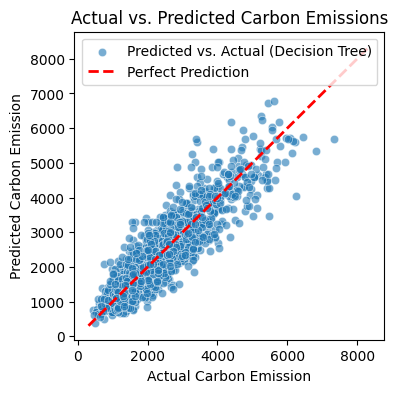

Decision Tree Plot for actual vs. predicted carbon emissions displayed successfully.


In [ ]:
plt.figure(figsize=(4, 4))
sns.scatterplot(x=y_test, y=y_pred_dt, alpha=0.6, label='Predicted vs. Actual (Decision Tree)')

# Add a perfect prediction line
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label='Perfect Prediction')

plt.xlabel('Actual Carbon Emission')
plt.ylabel('Predicted Carbon Emission')
plt.title('Actual vs. Predicted Carbon Emissions')
plt.legend()
plt.show()
print("Decision Tree Plot for actual vs. predicted carbon emissions displayed successfully.")

In [ ]:
model_rf = RandomForestRegressor(random_state=42)
model_rf.fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

results['Random Forest Regression'] = {
    'MAE': mae_rf,
    'MSE': mse_rf,
    'R2': r2_rf
}

print("Random Forest Regression model trained and evaluated successfully.")
print(f"Mean Absolute Error (MAE): {mae_rf:.2f}")
print(f"Mean Squared Error (MSE): {mse_rf:.2f}")
print(f"R-squared (R2): {r2_rf:.2f}")
print("\nFull results dictionary:")
print(results)

Random Forest Regression model trained and evaluated successfully.
Mean Absolute Error (MAE): 230.91
Mean Squared Error (MSE): 89686.90
R-squared (R2): 0.91

Full results dictionary:
{'Linear Regression': {'MAE': 175.62675416241314, 'MSE': 68441.94189977228, 'R2': 0.9341719789400711}, 'Ridge Regression': {'MAE': 175.58373283165264, 'MSE': 68421.17360255045, 'R2': 0.9341919540586745}, 'Polynomial Regression': {'MAE': 70.713701693148, 'MSE': 8663.770591833572, 'R2': 0.9916671143870699}, 'Decision Tree Regression': {'MAE': 354.618, 'MSE': 221179.524, 'R2': 0.787267719767234}, 'Random Forest Regression': {'MAE': 230.91238499999997, 'MSE': 89686.90026075, 'R2': 0.9137384037435672}}


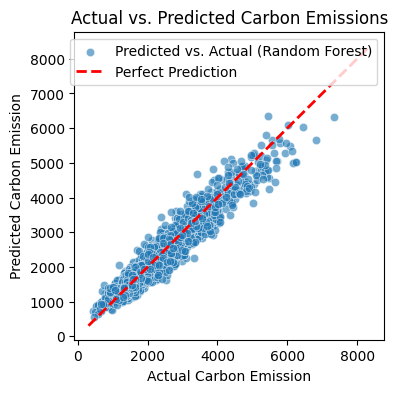

Random Forest Plot for actual vs. predicted carbon emissions displayed successfully.


In [ ]:
plt.figure(figsize=(4, 4))
sns.scatterplot(x=y_test, y=y_pred_rf, alpha=0.6, label='Predicted vs. Actual (Random Forest)')

# Add a perfect prediction line
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label='Perfect Prediction')

plt.xlabel('Actual Carbon Emission')
plt.ylabel('Predicted Carbon Emission')
plt.title('Actual vs. Predicted Carbon Emissions')
plt.legend()
plt.show()
print("Random Forest Plot for actual vs. predicted carbon emissions displayed successfully.")

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features scaled successfully for SVR model.")

Features scaled successfully for SVR model.


In [ ]:
model_sv = SVR(kernel='linear')
model_sv.fit(X_train_scaled, y_train)
y_pred_sv = model_sv.predict(X_test_scaled)

mae_sv = mean_absolute_error(y_test, y_pred_sv)
mse_sv = mean_squared_error(y_test, y_pred_sv)
r2_sv = r2_score(y_test, y_pred_sv)

results['Support Vector Regression'] = {
    'MAE': mae_sv,
    'MSE': mse_sv,
    'R2': r2_sv
}

print("Support Vector Regression model trained and evaluated successfully.")
print(f"Mean Absolute Error (MAE): {mae_sv:.2f}")
print(f"Mean Squared Error (MSE): {mse_sv:.2f}")
print(f"R-squared (R2): {r2_sv:.2f}")
print("\nFull results dictionary:")
print(results)

Support Vector Regression model trained and evaluated successfully.
Mean Absolute Error (MAE): 178.04
Mean Squared Error (MSE): 75532.68
R-squared (R2): 0.93

Full results dictionary:
{'Linear Regression': {'MAE': 175.62675416241314, 'MSE': 68441.94189977228, 'R2': 0.9341719789400711}, 'Ridge Regression': {'MAE': 175.58373283165264, 'MSE': 68421.17360255045, 'R2': 0.9341919540586745}, 'Polynomial Regression': {'MAE': 70.713701693148, 'MSE': 8663.770591833572, 'R2': 0.9916671143870699}, 'Decision Tree Regression': {'MAE': 354.618, 'MSE': 221179.524, 'R2': 0.787267719767234}, 'Random Forest Regression': {'MAE': 230.91238499999997, 'MSE': 89686.90026075, 'R2': 0.9137384037435672}, 'Support Vector Regression': {'MAE': 178.03949075221976, 'MSE': 75532.68414801503, 'R2': 0.9273520448895236}}


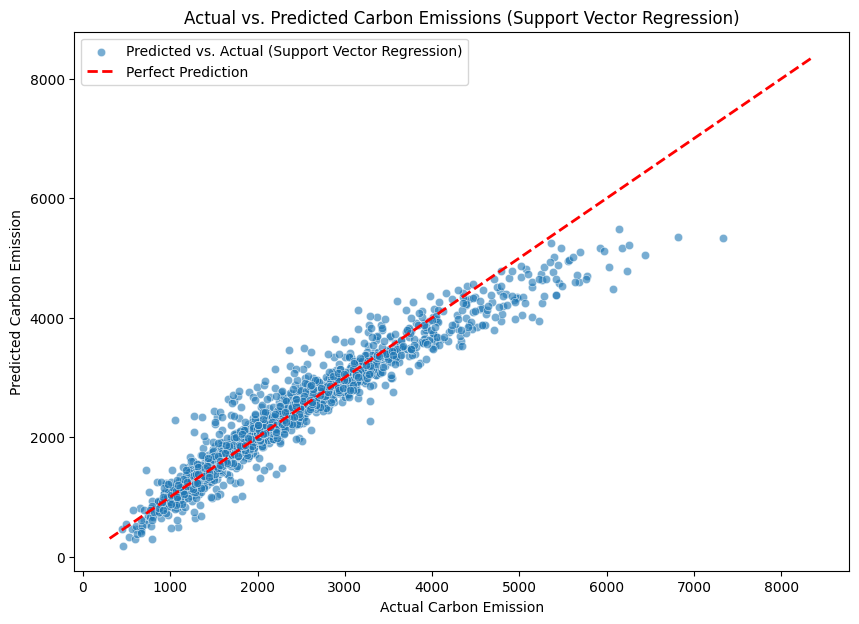

Support Vector Regression Plot for actual vs. predicted carbon emissions displayed successfully.


In [ ]:
plt.figure(figsize=(10, 7))
sns.scatterplot(x=y_test, y=y_pred_sv, alpha=0.6, label='Predicted vs. Actual (Support Vector Regression)')

# Add a perfect prediction line
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label='Perfect Prediction')

plt.xlabel('Actual Carbon Emission')
plt.ylabel('Predicted Carbon Emission')
plt.title('Actual vs. Predicted Carbon Emissions (Support Vector Regression)')
plt.legend()
plt.show()
print("Support Vector Regression Plot for actual vs. predicted carbon emissions displayed successfully.")

In [ ]:
model_ls = Lasso(alpha=0.1)
model_ls.fit(X_train, y_train)
y_pred_ls = model_ls.predict(X_test)

mae_ls = mean_absolute_error(y_test, y_pred_ls)
mse_ls = mean_squared_error(y_test, y_pred_ls)
r2_ls = r2_score(y_test, y_pred_ls)

results['Lasso Regression'] = {
    'MAE': mae_ls,
    'MSE': mse_ls,
    'R2': r2_ls
}

print("Lasso Regression model trained and evaluated successfully.")
print(f"Mean Absolute Error (MAE): {mae_ls:.2f}")
print(f"Mean Squared Error (MSE): {mse_ls:.2f}")
print(f"R-squared (R2): {r2_ls:.2f}")
print("\nFull results dictionary:")
print(results)

Lasso Regression model trained and evaluated successfully.
Mean Absolute Error (MAE): 175.48
Mean Squared Error (MSE): 68356.74
R-squared (R2): 0.93

Full results dictionary:
{'Linear Regression': {'MAE': 175.62675416241314, 'MSE': 68441.94189977228, 'R2': 0.9341719789400711}, 'Ridge Regression': {'MAE': 175.58373283165264, 'MSE': 68421.17360255045, 'R2': 0.9341919540586745}, 'Polynomial Regression': {'MAE': 70.713701693148, 'MSE': 8663.770591833572, 'R2': 0.9916671143870699}, 'Decision Tree Regression': {'MAE': 354.618, 'MSE': 221179.524, 'R2': 0.787267719767234}, 'Random Forest Regression': {'MAE': 230.91238499999997, 'MSE': 89686.90026075, 'R2': 0.9137384037435672}, 'Support Vector Regression': {'MAE': 178.03949075221976, 'MSE': 75532.68414801503, 'R2': 0.9273520448895236}, 'Lasso Regression': {'MAE': 175.4792098416919, 'MSE': 68356.73869284565, 'R2': 0.9342539280833049}}


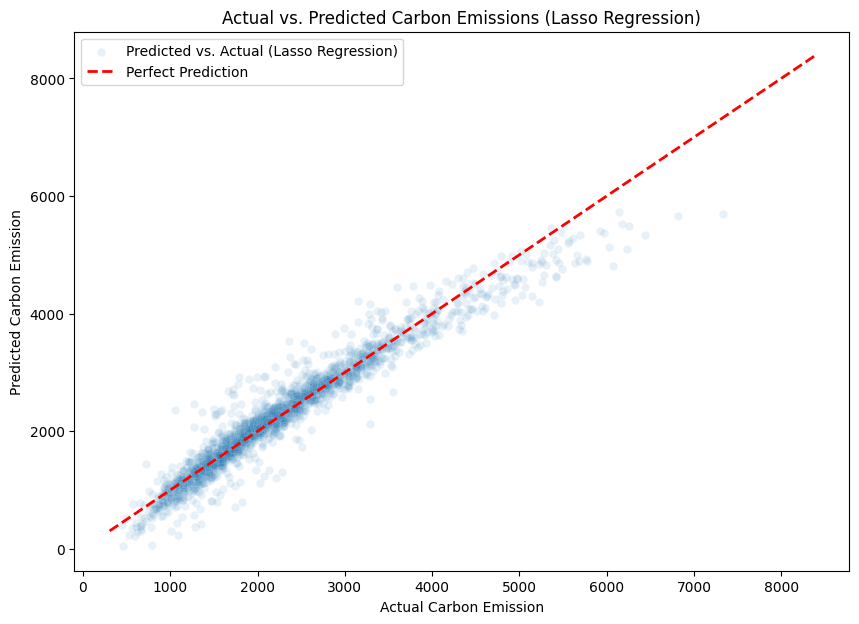

Lasso Regression Plot for actual vs. predicted carbon emissions displayed successfully.


In [ ]:
plt.figure(figsize=(10, 7))
sns.scatterplot(x=y_test, y=y_pred_ls, alpha=0.1, label='Predicted vs. Actual (Lasso Regression)')

# Add a perfect prediction line
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label='Perfect Prediction')

plt.xlabel('Actual Carbon Emission')
plt.ylabel('Predicted Carbon Emission')
plt.title('Actual vs. Predicted Carbon Emissions (Lasso Regression)')
plt.legend()
plt.show()
print("Lasso Regression Plot for actual vs. predicted carbon emissions displayed successfully.")

In [ ]:
model_en = ElasticNet(alpha=0.1, l1_ratio=0.5)
model_en.fit(X_train, y_train)
y_pred_en = model_en.predict(X_test)

mae_en = mean_absolute_error(y_test, y_pred_en)
mse_en = mean_squared_error(y_test, y_pred_en)
r2_en = r2_score(y_test, y_pred_en)

results['ElasticNet Regression'] = {
    'MAE': mae_en,
    'MSE': mse_en,
    'R2': r2_en
}

print("ElasticNet Regression model trained and evaluated successfully.")
print(f"Mean Absolute Error (MAE): {mae_en:.2f}")
print(f"Mean Squared Error (MSE): {mse_en:.2f}")
print(f"R-squared (R2): {r2_en:.2f}")
print("\nFull results dictionary:")
print(results)

ElasticNet Regression model trained and evaluated successfully.
Mean Absolute Error (MAE): 217.60
Mean Squared Error (MSE): 107213.37
R-squared (R2): 0.90

Full results dictionary:
{'Linear Regression': {'MAE': 175.62675416241314, 'MSE': 68441.94189977228, 'R2': 0.9341719789400711}, 'Ridge Regression': {'MAE': 175.58373283165264, 'MSE': 68421.17360255045, 'R2': 0.9341919540586745}, 'Polynomial Regression': {'MAE': 70.713701693148, 'MSE': 8663.770591833572, 'R2': 0.9916671143870699}, 'Decision Tree Regression': {'MAE': 354.618, 'MSE': 221179.524, 'R2': 0.787267719767234}, 'Random Forest Regression': {'MAE': 230.91238499999997, 'MSE': 89686.90026075, 'R2': 0.9137384037435672}, 'Support Vector Regression': {'MAE': 178.03949075221976, 'MSE': 75532.68414801503, 'R2': 0.9273520448895236}, 'Lasso Regression': {'MAE': 175.4792098416919, 'MSE': 68356.73869284565, 'R2': 0.9342539280833049}, 'ElasticNet Regression': {'MAE': 217.60055698409803, 'MSE': 107213.36706512586, 'R2': 0.8968813042241797}}

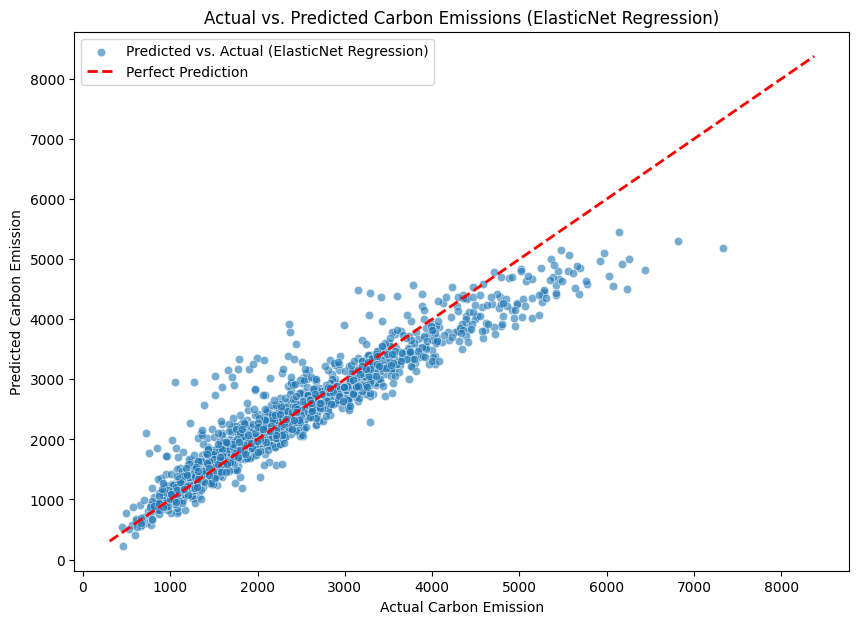

ElasticNet Regression Plot for actual vs. predicted carbon emissions displayed successfully.


In [ ]:
plt.figure(figsize=(10, 7))
sns.scatterplot(x=y_test, y=y_pred_en, alpha=0.6, label='Predicted vs. Actual (ElasticNet Regression)')

# Add a perfect prediction line
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label='Perfect Prediction')

plt.xlabel('Actual Carbon Emission')
plt.ylabel('Predicted Carbon Emission')
plt.title('Actual vs. Predicted Carbon Emissions (ElasticNet Regression)')
plt.legend()
plt.show()
print("ElasticNet Regression Plot for actual vs. predicted carbon emissions displayed successfully.")

In [ ]:
model_bl = BayesianRidge()
model_bl.fit(X_train, y_train)
y_pred_bl = model_bl.predict(X_test)

mae_bl = mean_absolute_error(y_test, y_pred_bl)
mse_bl = mean_squared_error(y_test, y_pred_bl)
r2_bl = r2_score(y_test, y_pred_bl)

results['Bayesian Regression'] = {
    'MAE': mae_bl,
    'MSE': mse_bl,
    'R2': r2_bl
}

print("Bayesian Regression model trained and evaluated successfully.")
print(f"Mean Absolute Error (MAE): {mae_bl:.2f}")
print(f"Mean Squared Error (MSE): {mse_bl:.2f}")
print(f"R-squared (R2): {r2_bl:.2f}")
print("\nFull results dictionary:")
print(results)

Bayesian Regression model trained and evaluated successfully.
Mean Absolute Error (MAE): 175.58
Mean Squared Error (MSE): 68420.24
R-squared (R2): 0.93

Full results dictionary:
{'Linear Regression': {'MAE': 175.62675416241314, 'MSE': 68441.94189977228, 'R2': 0.9341719789400711}, 'Ridge Regression': {'MAE': 175.58373283165264, 'MSE': 68421.17360255045, 'R2': 0.9341919540586745}, 'Polynomial Regression': {'MAE': 70.713701693148, 'MSE': 8663.770591833572, 'R2': 0.9916671143870699}, 'Decision Tree Regression': {'MAE': 354.618, 'MSE': 221179.524, 'R2': 0.787267719767234}, 'Random Forest Regression': {'MAE': 230.91238499999997, 'MSE': 89686.90026075, 'R2': 0.9137384037435672}, 'Support Vector Regression': {'MAE': 178.03949075221976, 'MSE': 75532.68414801503, 'R2': 0.9273520448895236}, 'Lasso Regression': {'MAE': 175.4792098416919, 'MSE': 68356.73869284565, 'R2': 0.9342539280833049}, 'ElasticNet Regression': {'MAE': 217.60055698409803, 'MSE': 107213.36706512586, 'R2': 0.8968813042241797}, 'B

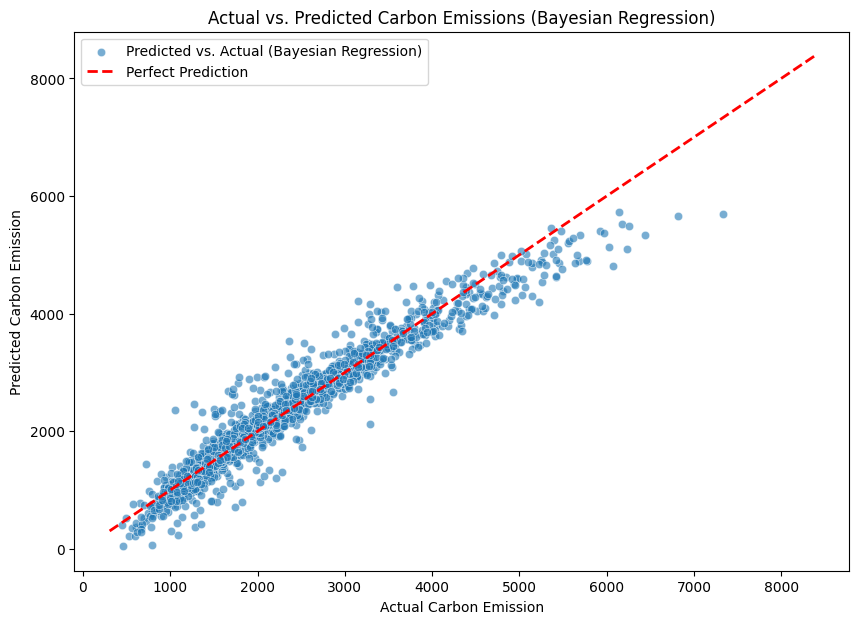

Bayesian Regression Plot for actual vs. predicted carbon emissions displayed successfully.


In [ ]:
plt.figure(figsize=(10, 7))
sns.scatterplot(x=y_test, y=y_pred_bl, alpha=0.6, label='Predicted vs. Actual (Bayesian Regression)')

# Add a perfect prediction line
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label='Perfect Prediction')

plt.xlabel('Actual Carbon Emission')
plt.ylabel('Predicted Carbon Emission')
plt.title('Actual vs. Predicted Carbon Emissions (Bayesian Regression)')
plt.legend()
plt.show()
print("Bayesian Regression Plot for actual vs. predicted carbon emissions displayed successfully.")